We are building a LInera Regrssion Model to predict the median house value(MedHouseValue) based on the features like income, house age, average rooms, population, and location.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing

In [2]:
housing = fetch_california_housing() #housig contaions the data in numpy form. It is not needed if we want the dataset in dataframe form.
data = fetch_california_housing(as_frame = True).frame # so we are using the as_frame = tue to convert the numpy form into pandas dataframe

In [3]:
housing = fetch_california_housing()
data = fetch_california_housing(as_frame = True).frame # housing contaions the data in numpy form 

In [4]:
#EG:
housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [5]:
data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [6]:
data.shape

(20640, 9)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [8]:
data.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [9]:
print(data.isnull().sum())

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


Dataset has no MIssing Value

In [10]:
print(data.duplicated().sum())

0


There is no duplicated value in the dataset

Corelation Heatmap

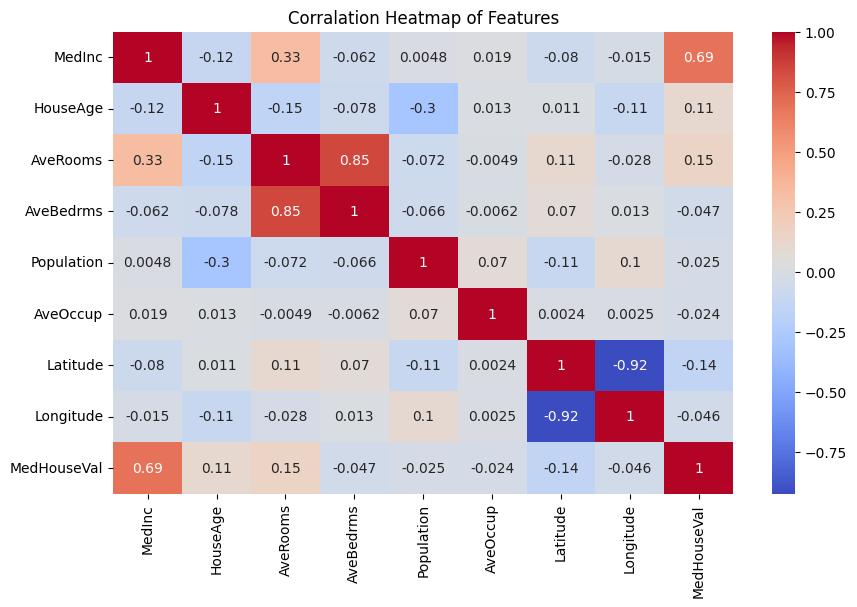

In [11]:
plt.figure(figsize = (10,6))
sns.heatmap(data.corr(), annot = True, cmap = 'coolwarm')
# sns. heatmap(dta.corr()) - to fing the correlation of all numerical columns in the daatset, and then show it in a heatmap,
# annot = True - is given to show not only the colours but also the correlation value of it in the box.
#cmap = coolwarm - is the color scheme
plt.title('Corralation Heatmap of Features')
plt.show()

In [12]:
x = data.drop('MedHouseVal', axis = 1)
y = data['MedHouseVal']

In [13]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [14]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [15]:
print(x_train.shape)
print(x_test.shape)

(16512, 8)
(4128, 8)


In [16]:
print(x_train_scaled.shape)
print(x_test_scaled.shape)

(16512, 8)
(4128, 8)


In [17]:
print(x_train_scaled)

[[-0.326196    0.34849025 -0.17491646 ...  0.05137609 -1.3728112
   1.27258656]
 [-0.03584338  1.61811813 -0.40283542 ... -0.11736222 -0.87669601
   0.70916212]
 [ 0.14470145 -1.95271028  0.08821601 ... -0.03227969 -0.46014647
  -0.44760309]
 ...
 [-0.49697313  0.58654547 -0.60675918 ...  0.02030568 -0.75500738
   0.59946887]
 [ 0.96545045 -1.07984112  0.40217517 ...  0.00707608  0.90651045
  -1.18553953]
 [-0.68544764  1.85617335 -0.85144571 ... -0.08535429  0.99543676
  -1.41489815]]


In [18]:
model = LinearRegression()
model.fit(x_train_scaled, y_train)

LinearRegression()

In [19]:
y_pred = model.predict(x_test_scaled)

Evaluation

In [20]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('intercept:',model.intercept_)
print('coefficients:',model.coef_)
print('mse:',mse)
print('r2 score:',r2)

intercept: 2.0719469373788777
coefficients: [ 0.85438303  0.12254624 -0.29441013  0.33925949 -0.00230772 -0.0408291
 -0.89692888 -0.86984178]
mse: 0.5558915986952444
r2 score: 0.5757877060324508


Feature importahnce - To find which feature has highly influence on the target column

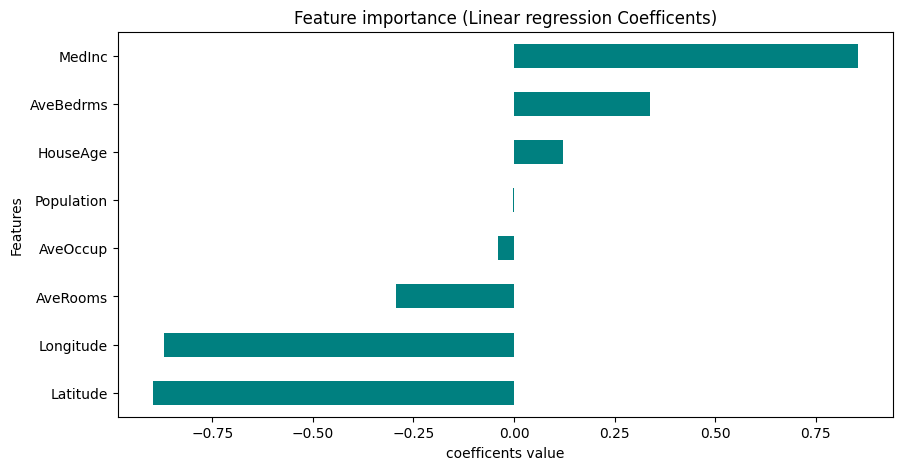

In [21]:
feature_importance = pd.Series(model.coef_, index = x.columns) # coef values learned by the model, and the respective column names
#model.coef_ → the coefficient values learned by the linear regression model, X.columns → the names of the features
plt.figure(figsize = (10,5))
feature_importance.sort_values().plot(kind= 'barh', color = 'teal') # sorting the coeffeicents, since there are negative and positive values, the sorting helps to arrange them from negative to positive
plt.title('Feature importance (Linear regression Coefficents)')
plt.xlabel('coefficents value')
plt.ylabel('Features')
plt.show()

Medain Income has the highest positive corelation - higher the income, higher the house values.
Lat and Long has the highest negative corralation - houses further inland has lower values
Averooma snd House Age also slightly increase prices
Avgroomas shows negative relationship
Popn and Aveoccup have very small impact - they only contribute little.
Income and Location are the major drivers of house prices.

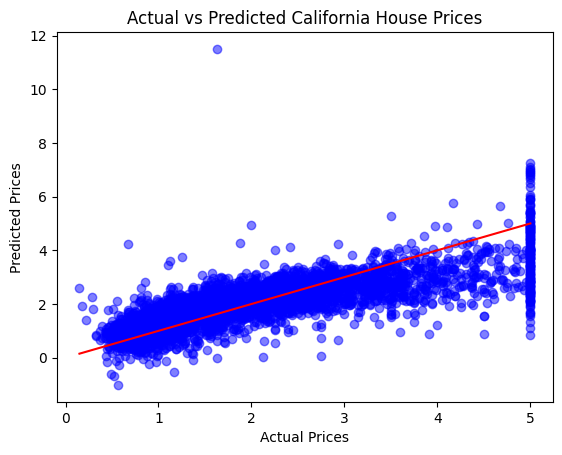

In [22]:
plt.scatter(y_test, y_pred, color = 'blue', alpha = 0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color = 'red')
# here we are plotting the straight red line- plt.plot([x,y], color = 'red'), x = min(y_test), max(y_test), y = min(y_test), max(y_test)
# Here, if y_test = [1.5,23,4.5,67], then x becomes min(y_test) = 1.5, max(y_test) = 67, so x = (1.5,67) and similarrly y =(1.5,67)
# now we plot using x =(1.5, 67) ang y=(1.5, 67) that is (1.5, 1.5), (67,67)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted California House Prices')
plt.show()

In [23]:
new = np.array([[8, 20, 5, 1, 1000, 3, 34, -118]])
n = scaler.transform(new) # since the old data is scaled, the new data also need to be scaled
# we dont use fit_transform(), because we dont want to create a new scaling system, we must use the same scaling system used during traing.
predicted_value = model.predict(n)[0]
print(f'Predicted house value: ${predicted_value * 100000:.2f}') # converting the predicted value to dollars

Predicted house value: $381913.35


C:\Users\POOJA\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
